In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(" Бібліотеки завантажено!")

 Бібліотеки завантажено!


In [2]:
# Завантаження Adult (Census Income) Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Назви колонок
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Завантаження даних (пропуски позначені як ' ?')
df = pd.read_csv(url, names=column_names, sep=',\s*', engine='python', na_values=' ?')

print(f" Датасет завантажено!")
print(f"Розмір: {df.shape}")
print(f"\nПерші 5 рядків:")
df.head()

 Датасет завантажено!
Розмір: (32561, 15)

Перші 5 рядків:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# Інформація про датасет
print("ІНФОРМАЦІЯ ПРО ДАТАСЕТ")
df.info()

print("ПРОПУЩЕНІ ЗНАЧЕННЯ")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Кількість пропущених': missing_values,
    'Відсоток': missing_percent
})

missing_df = missing_df[missing_df['Кількість пропущених'] > 0].sort_values(
    by='Кількість пропущених', ascending=False
)

print(missing_df)
print(f"\n Загальна кількість пропусків: {df.isnull().sum().sum()}")

ІНФОРМАЦІЯ ПРО ДАТАСЕТ
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
ПРОПУЩЕНІ ЗНАЧЕННЯ
Empty DataFrame
Columns: [Кількість пропущених, Відсоток]
Index: []

 Загальна кіль

In [6]:
# Перевірка на приховані пропуски (символ '?')
print("Перевірка на '?' у колонках:")
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'str':
        count = (df[col] == '?').sum()
        if count > 0:
            print(f"  {col}: {count} значень '?'")

# Заміна '?' на NaN
df.replace('?', np.nan, inplace=True)

print("ПРОПУЩЕНІ ЗНАЧЕННЯ ПІСЛЯ ВИПРАВЛЕННЯ")

missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Кількість пропущених': missing_values,
    'Відсоток': missing_percent
})

missing_df = missing_df[missing_df['Кількість пропущених'] > 0].sort_values(
    by='Кількість пропущених', ascending=False
)

print(missing_df)
print(f"\n Загальна кількість пропусків: {df.isnull().sum().sum()}")

Перевірка на '?' у колонках:
ПРОПУЩЕНІ ЗНАЧЕННЯ ПІСЛЯ ВИПРАВЛЕННЯ
                Кількість пропущених  Відсоток
occupation                      1843  5.660146
workclass                       1836  5.638647
native_country                   583  1.790486

 Загальна кількість пропусків: 4262


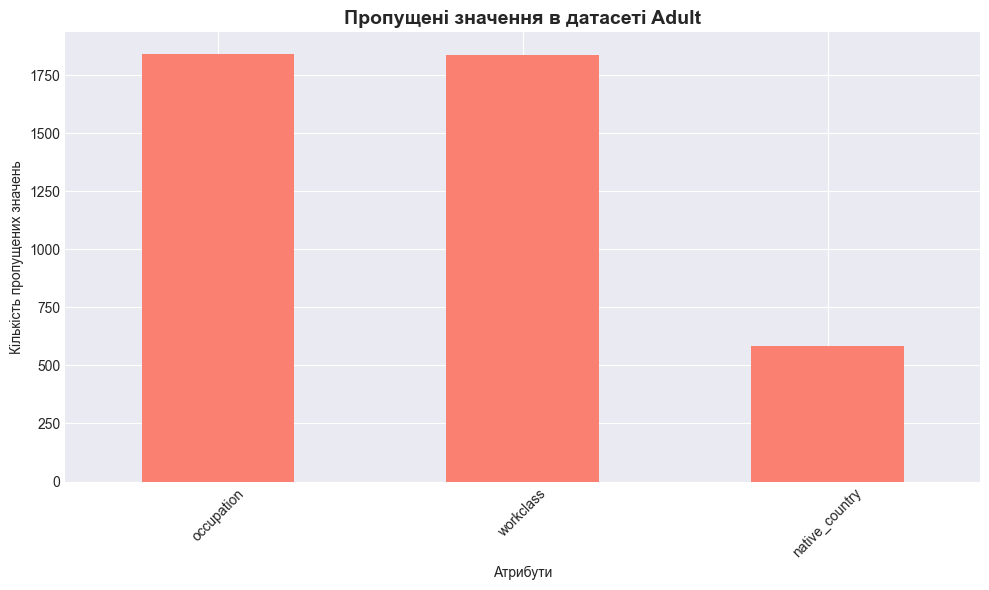

 Графік пропусків створено!


In [7]:
# Візуалізація пропущених значень
fig, ax = plt.subplots(figsize=(10, 6))
missing_df['Кількість пропущених'].plot(kind='bar', color='salmon', ax=ax)
ax.set_title('Пропущені значення в датасеті Adult', fontsize=14, fontweight='bold')
ax.set_xlabel('Атрибути')
ax.set_ylabel('Кількість пропущених значень')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(" Графік пропусків створено!")

In [10]:
# Видаляємо рядки з пропусками 
print(f"Розмір до видалення: {df_clean.shape}")

df_clean = df_clean.dropna()

print(f"Розмір після видалення: {df_clean.shape}")
print(f"Видалено рядків: {32561 - len(df_clean)}")
print(f"\n Пропусків після очищення: {df_clean.isnull().sum().sum()}")

print("\n Data Cleaning ЗАВЕРШЕНО!")

Розмір до видалення: (32561, 15)
Розмір після видалення: (30162, 15)
Видалено рядків: 2399

 Пропусків після очищення: 0

 Data Cleaning ЗАВЕРШЕНО!


In [11]:
# Статистика очищеного датасету
print("=" * 60)
print("СТАТИСТИКА ЧИСЛОВИХ ЗМІННИХ")
print("=" * 60)
print(df_clean.describe())

print("\n" + "=" * 60)
print("РОЗПОДІЛ ЗА ДОХОДОМ")
print("=" * 60)
print(df_clean['income'].value_counts())

print("\n" + "=" * 60)
print("РОЗПОДІЛ ЗА СТАТТЮ")
print("=" * 60)
print(df_clean['sex'].value_counts())

СТАТИСТИКА ЧИСЛОВИХ ЗМІННИХ
                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  30162.000000  3.016200e+04   30162.000000  30162.000000  30162.000000   
mean      38.437902  1.897938e+05      10.121312   1092.007858     88.372489   
std       13.134665  1.056530e+05       2.549995   7406.346497    404.298370   
min       17.000000  1.376900e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.176272e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.784250e+05      10.000000      0.000000      0.000000   
75%       47.000000  2.376285e+05      13.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    30162.000000  
mean        40.931238  
std         11.979984  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

РОЗПОДІЛ ЗА ДОХОДОМ
income
<=50K  

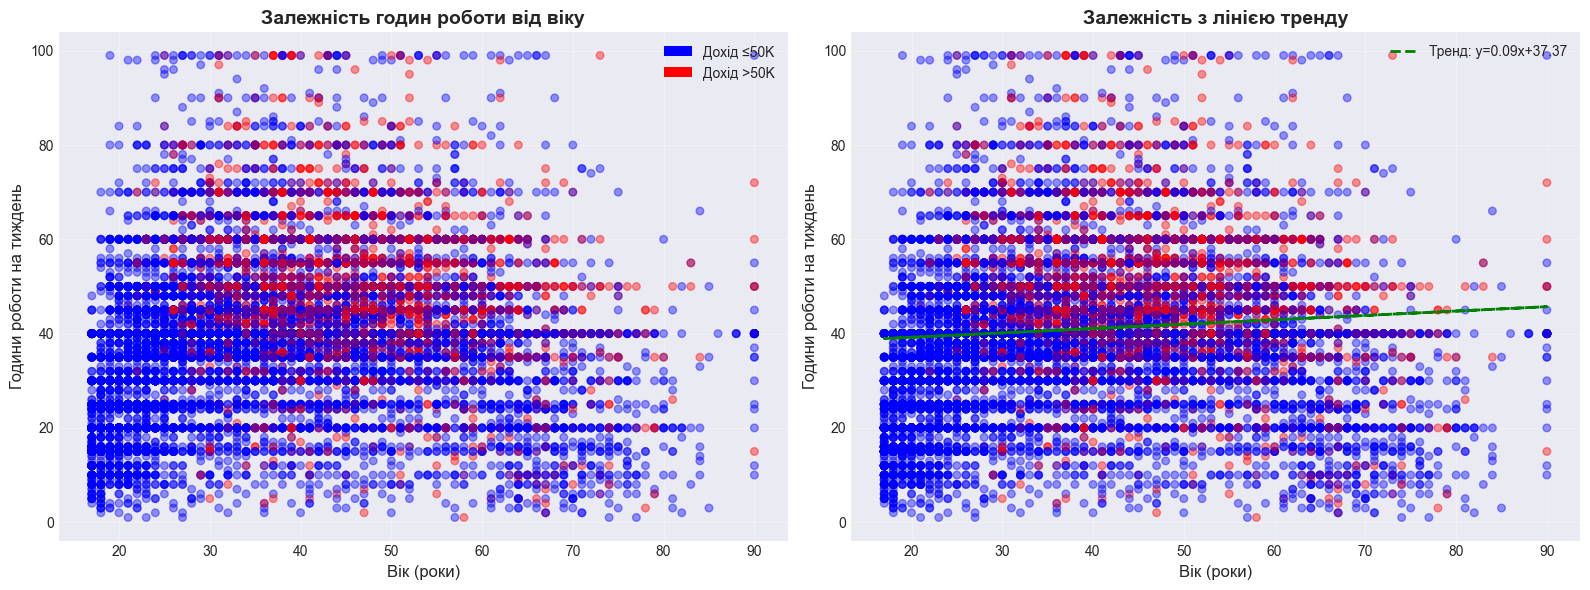


 Кореляція між віком та годинами роботи: 0.102


In [12]:
# Scatter plot: Вік vs Години роботи на тиждень
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1 - з кольором за доходом
colors = df_clean['income'].map({'<=50K': 'blue', '>50K': 'red'})
axes[0].scatter(df_clean['age'], df_clean['hours_per_week'], 
               c=colors, alpha=0.4, s=30)
axes[0].set_xlabel('Вік (роки)', fontsize=12)
axes[0].set_ylabel('Години роботи на тиждень', fontsize=12)
axes[0].set_title('Залежність годин роботи від віку', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Дохід ≤50K'),
                  Patch(facecolor='red', label='Дохід >50K')]
axes[0].legend(handles=legend_elements)

# Графік 2 - з лінією тренду
axes[1].scatter(df_clean['age'], df_clean['hours_per_week'], 
               c=colors, alpha=0.4, s=30)

# Лінія тренду
z = np.polyfit(df_clean['age'], df_clean['hours_per_week'], 1)
p = np.poly1d(z)
axes[1].plot(df_clean['age'], p(df_clean['age']), 
            "g--", linewidth=2, label=f'Тренд: y={z[0]:.2f}x+{z[1]:.2f}')

axes[1].set_xlabel('Вік (роки)', fontsize=12)
axes[1].set_ylabel('Години роботи на тиждень', fontsize=12)
axes[1].set_title('Залежність з лінією тренду', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Кореляція
correlation = df_clean['age'].corr(df_clean['hours_per_week'])
print(f"\n Кореляція між віком та годинами роботи: {correlation:.3f}")

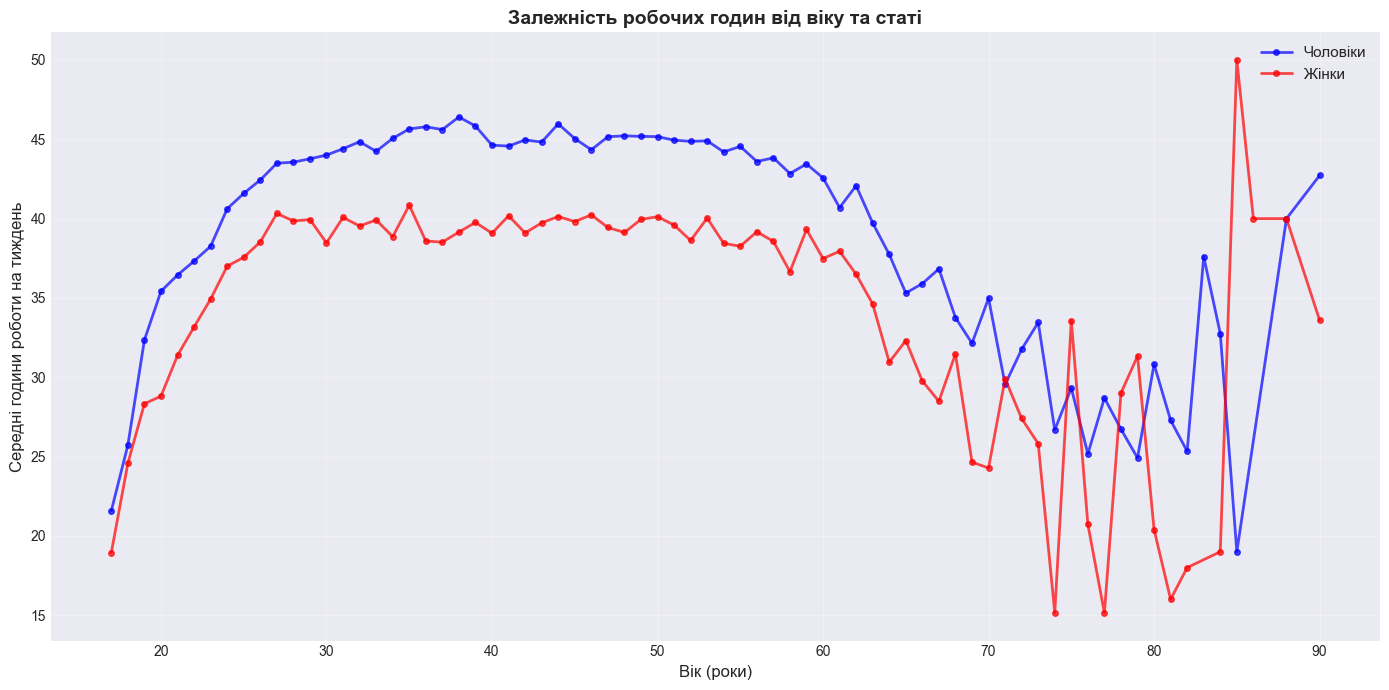

 Line Plot створено!


In [13]:
# Line Plot: Середні години роботи за віком та статтю
df_grouped = df_clean.groupby(['age', 'sex'])['hours_per_week'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))

# Розділення за статтю
male_data = df_grouped[df_grouped['sex'] == 'Male']
female_data = df_grouped[df_grouped['sex'] == 'Female']

ax.plot(male_data['age'], male_data['hours_per_week'], 
        'o-', alpha=0.7, label='Чоловіки', color='blue', linewidth=2, markersize=4)
ax.plot(female_data['age'], female_data['hours_per_week'], 
        'o-', alpha=0.7, label='Жінки', color='red', linewidth=2, markersize=4)

ax.set_xlabel('Вік (роки)', fontsize=12)
ax.set_ylabel('Середні години роботи на тиждень', fontsize=12)
ax.set_title('Залежність робочих годин від віку та статі', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Line Plot створено!")

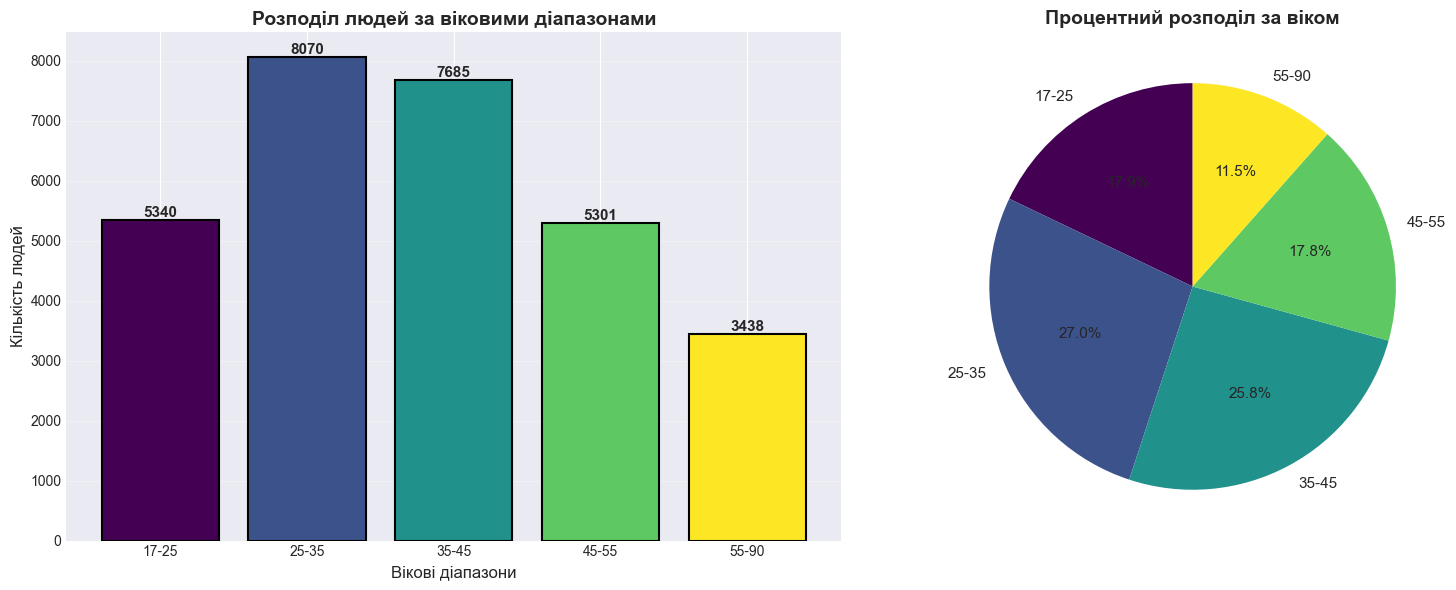


 Детальна статистика по діапазонах:
age_range
17-25    5340
25-35    8070
35-45    7685
45-55    5301
55-90    3438
Name: count, dtype: int64


In [14]:
# Визначення 5 діапазонів віку
age_bins = [17, 25, 35, 45, 55, 90]
age_labels = ['17-25', '25-35', '35-45', '45-55', '55-90']

df_clean['age_range'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)

# Підрахунок кількості в кожному діапазоні
age_counts = df_clean['age_range'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гістограма
colors_hist = plt.cm.viridis(np.linspace(0, 1, len(age_counts)))
bars = axes[0].bar(age_counts.index, age_counts.values, color=colors_hist, 
                   edgecolor='black', linewidth=1.5)

# Додавання значень на стовпчики
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_xlabel('Вікові діапазони', fontsize=12)
axes[0].set_ylabel('Кількість людей', fontsize=12)
axes[0].set_title('Розподіл людей за віковими діапазонами', 
                  fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%',
           colors=colors_hist, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Процентний розподіл за віком', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Детальна статистика по діапазонах:")
print(age_counts)

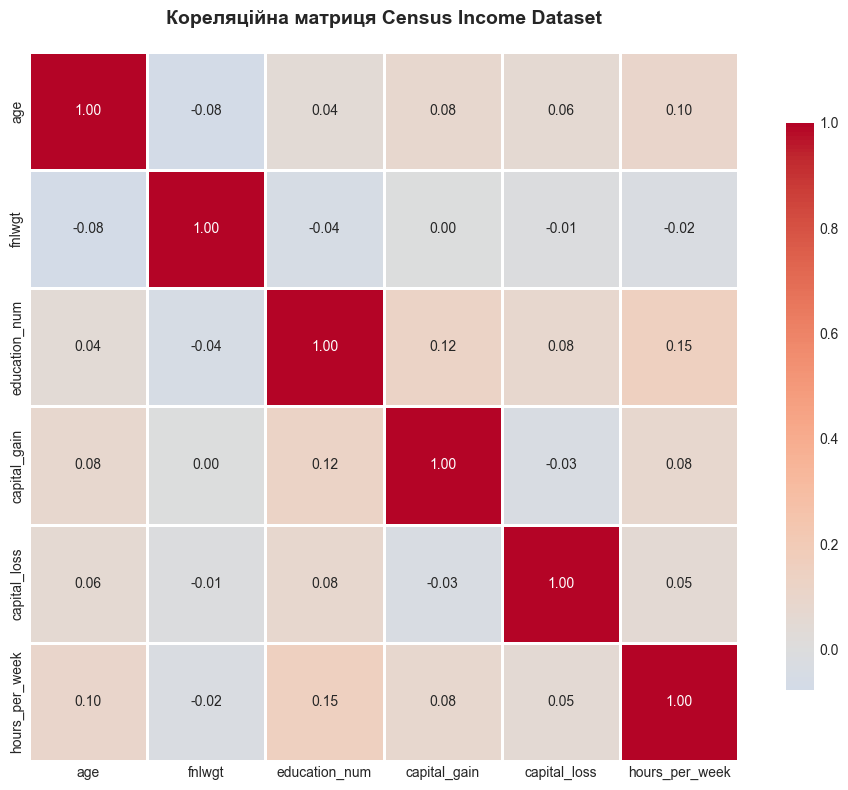


 Найсильніші кореляції:
hours_per_week  education_num     0.152522
education_num   hours_per_week    0.152522
                capital_gain      0.124416
capital_gain    education_num     0.124416
hours_per_week  age               0.101599
dtype: float64


In [15]:
# Вибір числових колонок для кореляції
numeric_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 
                'capital_loss', 'hours_per_week']
correlation_matrix = df_clean[numeric_cols].corr()

# Створення heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0,
            square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8},
            ax=ax)

ax.set_title('Кореляційна матриця Census Income Dataset', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n Найсильніші кореляції:")
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
print(corr_pairs.sort_values(ascending=False).head(5))

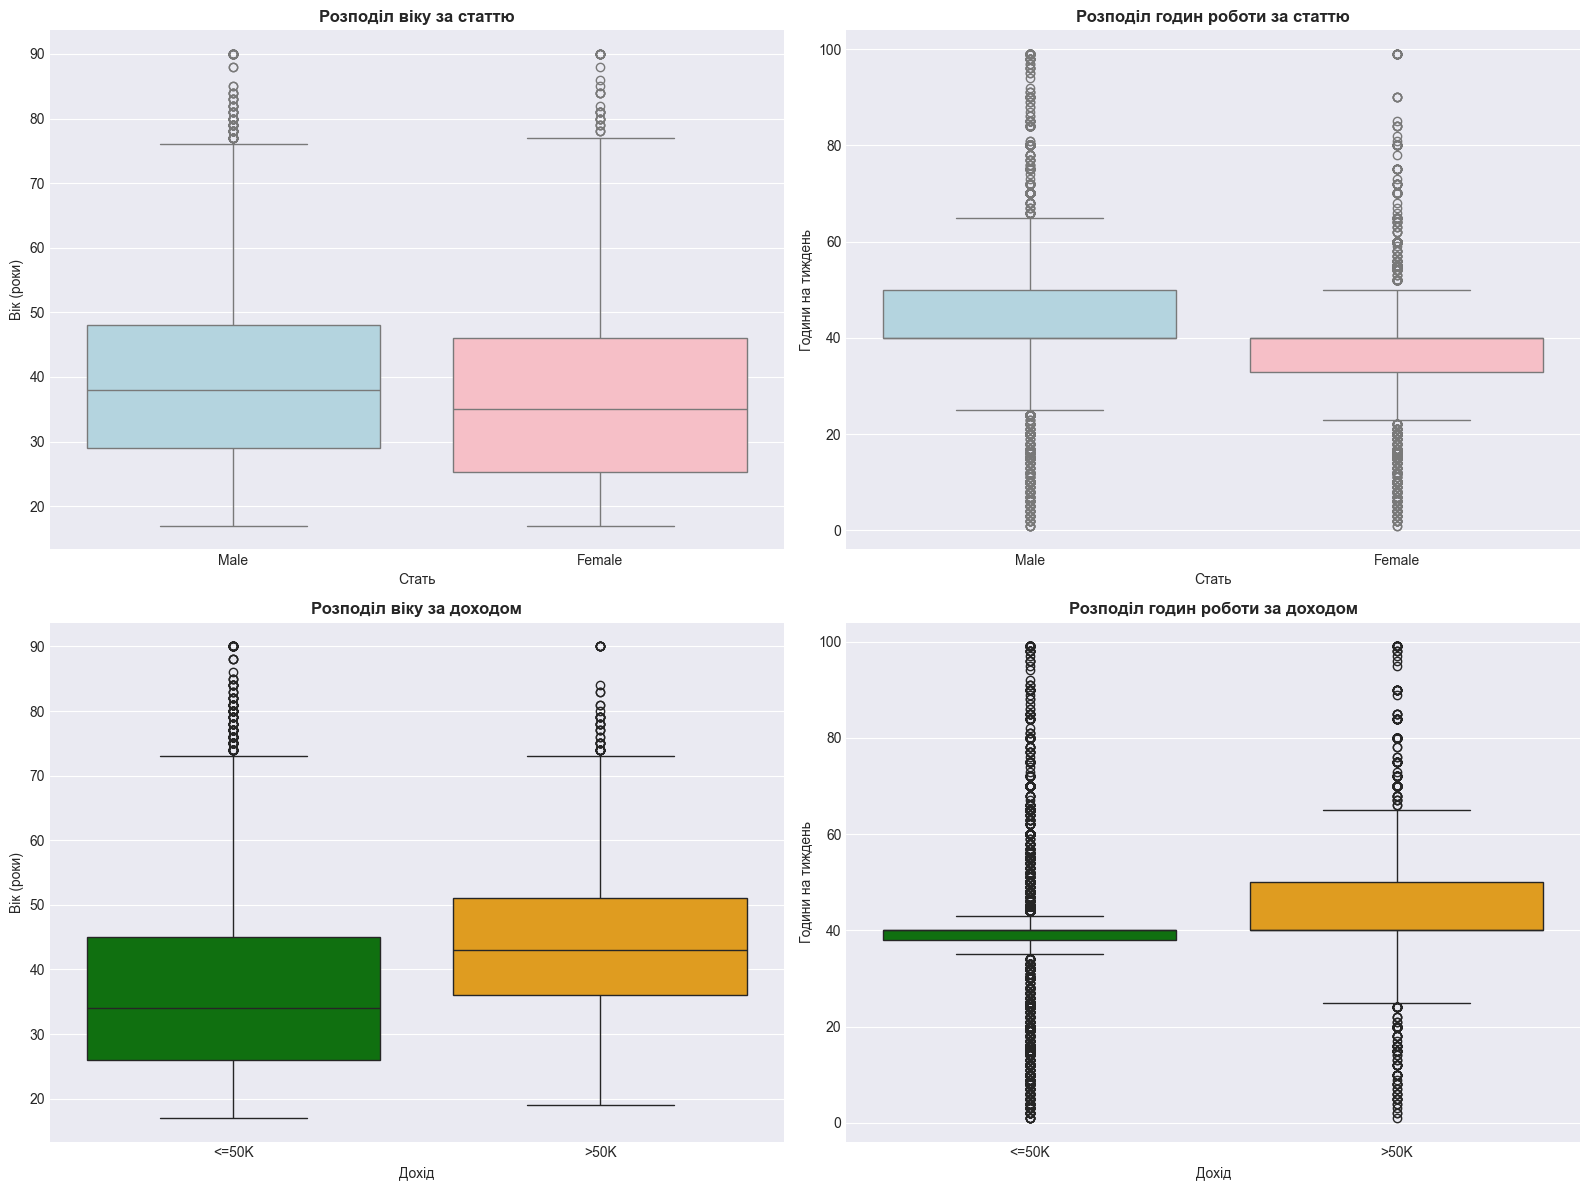

Box Plot створено!


In [16]:
# Box Plot: Розподіл показників за статтю та доходом
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Вік за статтю
sns.boxplot(data=df_clean, x='sex', y='age', 
            palette=['lightblue', 'lightpink'], ax=axes[0, 0])
axes[0, 0].set_title('Розподіл віку за статтю', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Стать')
axes[0, 0].set_ylabel('Вік (роки)')

# Години роботи за статтю
sns.boxplot(data=df_clean, x='sex', y='hours_per_week', 
            palette=['lightblue', 'lightpink'], ax=axes[0, 1])
axes[0, 1].set_title('Розподіл годин роботи за статтю', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Стать')
axes[0, 1].set_ylabel('Години на тиждень')

# Вік за доходом
sns.boxplot(data=df_clean, x='income', y='age', 
            palette=['green', 'orange'], ax=axes[1, 0])
axes[1, 0].set_title('Розподіл віку за доходом', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Дохід')
axes[1, 0].set_ylabel('Вік (роки)')

# Години роботи за доходом
sns.boxplot(data=df_clean, x='income', y='hours_per_week', 
            palette=['green', 'orange'], ax=axes[1, 1])
axes[1, 1].set_title('Розподіл годин роботи за доходом', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Дохід')
axes[1, 1].set_ylabel('Години на тиждень')

plt.tight_layout()
plt.show()

print("Box Plot створено!")

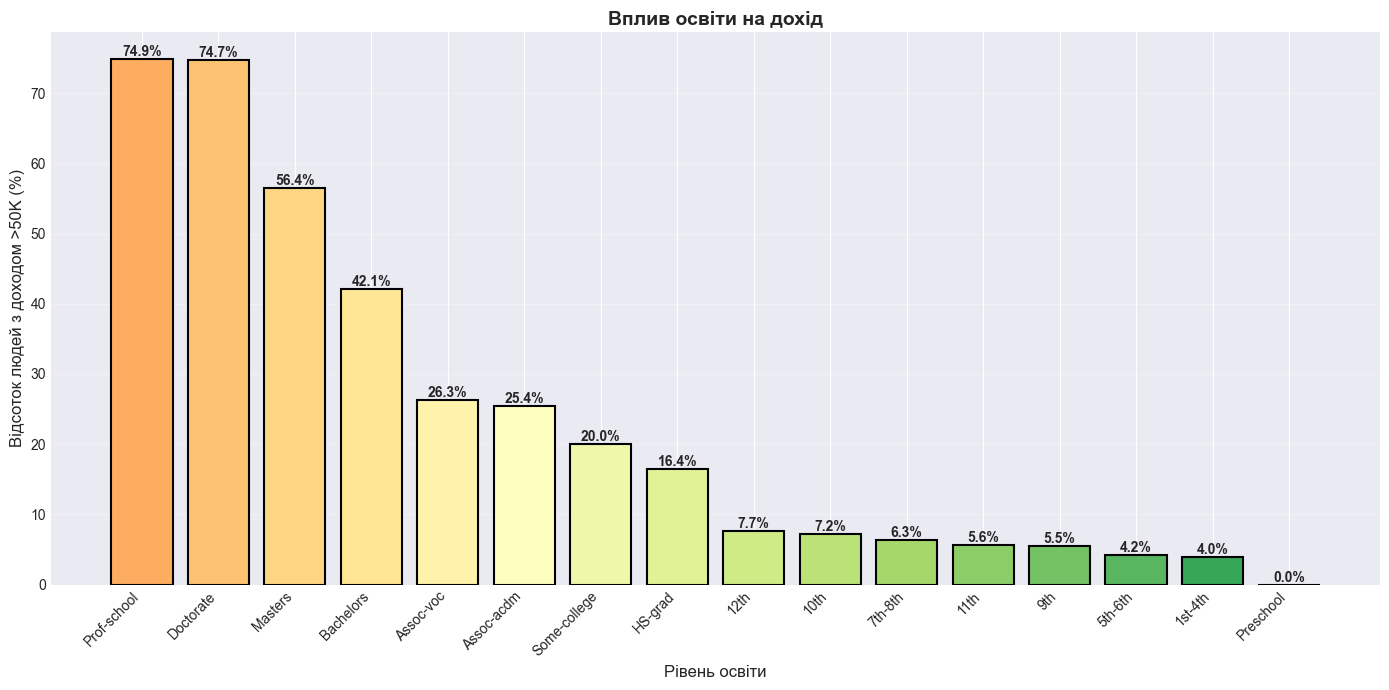


 Найвища освіта = найбільший дохід: Prof-school (74.9%)


In [17]:
# Bar Chart: Рівень освіти та відсоток людей з високим доходом
education_income = df_clean.groupby('education')['income'].apply(
    lambda x: (x == '>50K').sum() / len(x) * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))

colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(education_income)))
bars = ax.bar(range(len(education_income)), education_income.values, 
              color=colors_bar, edgecolor='black', linewidth=1.5)

# Додавання значень
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(education_income)))
ax.set_xticklabels(education_income.index, rotation=45, ha='right')
ax.set_xlabel('Рівень освіти', fontsize=12)
ax.set_ylabel('Відсоток людей з доходом >50K (%)', fontsize=12)
ax.set_title('Вплив освіти на дохід', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Найвища освіта = найбільший дохід: {education_income.index[0]} ({education_income.values[0]:.1f}%)")

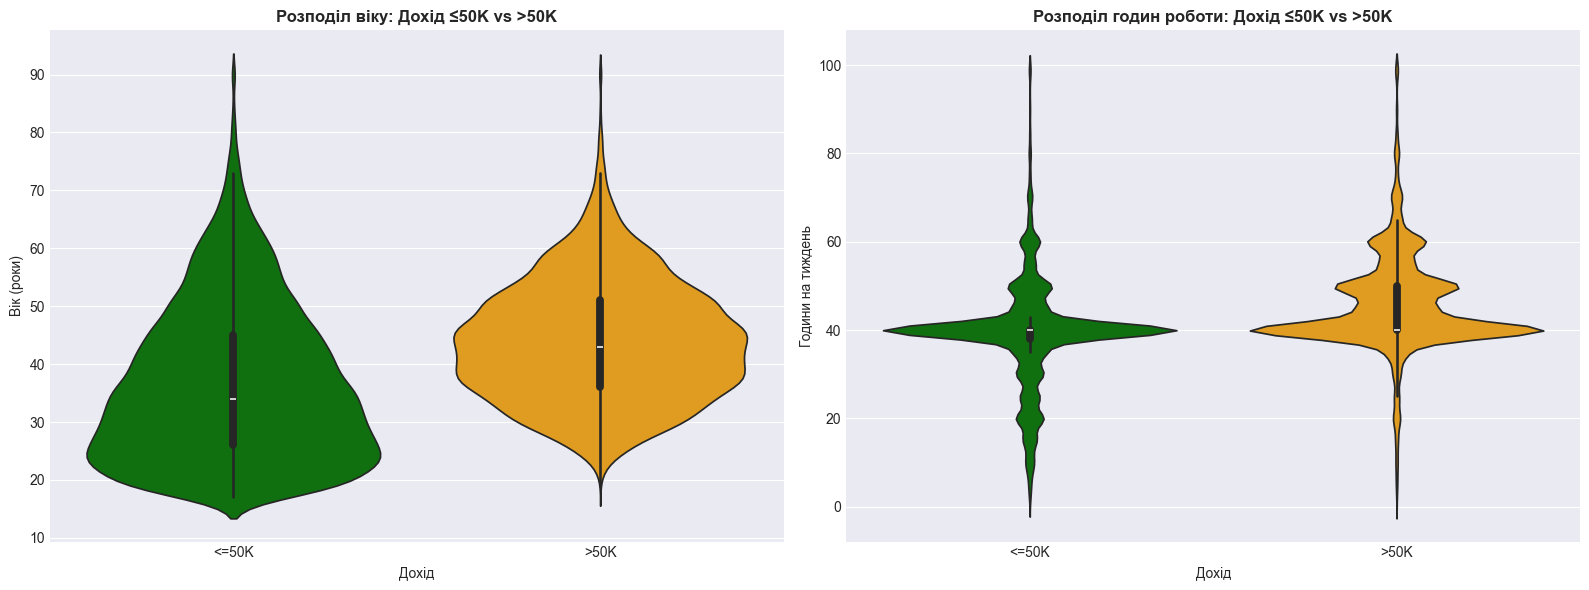

 Violin Plot створено!


In [18]:
# Violin Plot: Розподіл віку за доходом та статтю
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot для віку за доходом
sns.violinplot(data=df_clean, x='income', y='age', 
               palette=['green', 'orange'], ax=axes[0])
axes[0].set_title('Розподіл віку: Дохід ≤50K vs >50K', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Дохід')
axes[0].set_ylabel('Вік (роки)')

# Violin plot для годин роботи за доходом
sns.violinplot(data=df_clean, x='income', y='hours_per_week', 
               palette=['green', 'orange'], ax=axes[1])
axes[1].set_title('Розподіл годин роботи: Дохід ≤50K vs >50K', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Дохід')
axes[1].set_ylabel('Години на тиждень')

plt.tight_layout()
plt.show()

print(" Violin Plot створено!")

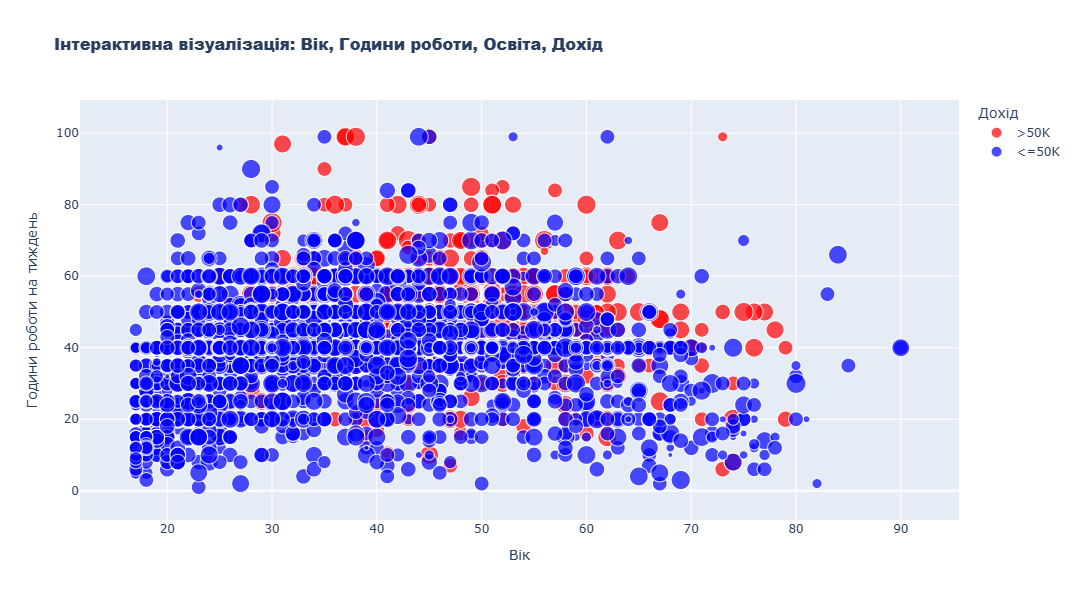

 Інтерактивний графік створено!


In [20]:
# Інтерактивний scatter plot з Plotly
# Беремо вибірку для швидкості (перші 5000 записів)
df_sample = df_clean.sample(n=5000, random_state=42)

fig = px.scatter(df_sample, 
                x='age', 
                y='hours_per_week',
                color='income',
                size='education_num',
                hover_data=['education', 'occupation', 'sex'],
                color_discrete_map={'<=50K': 'blue', '>50K': 'red'},
                labels={
                    'age': 'Вік',
                    'hours_per_week': 'Години роботи на тиждень',
                    'income': 'Дохід',
                    'education_num': 'Рівень освіти'
                },
                title='Інтерактивна візуалізація: Вік, Години роботи, Освіта, Дохід')

fig.update_layout(
    font=dict(size=12),
    title_font=dict(size=16, family='Arial Black'),
    height=600
)

fig.show()

print(" Інтерактивний графік створено!")


In [22]:
print("ПІДСУМКОВА СТАТИСТИКА ТА ВИСНОВКИ")

print("\n1. ЗАГАЛЬНА ІНФОРМАЦІЯ:")
print(f"   - Всього записів після очищення: {len(df_clean)}")
print(f"   - Людей з доходом >50K: {(df_clean['income'] == '>50K').sum()} ({(df_clean['income'] == '>50K').mean()*100:.1f}%)")
print(f"   - Людей з доходом ≤50K: {(df_clean['income'] == '<=50K').sum()} ({(df_clean['income'] == '<=50K').mean()*100:.1f}%)")

print("\n2. ДЕМОГРАФІЯ:")
print(f"   - Середній вік: {df_clean['age'].mean():.1f} років")
print(f"   - Чоловіків: {(df_clean['sex'] == 'Male').sum()} ({(df_clean['sex'] == 'Male').mean()*100:.1f}%)")
print(f"   - Жінок: {(df_clean['sex'] == 'Female').sum()} ({(df_clean['sex'] == 'Female').mean()*100:.1f}%)")

print("\n3. РОБОЧІ ПОКАЗНИКИ:")
print(f"   - Середні години роботи: {df_clean['hours_per_week'].mean():.1f} годин/тиждень")
print(f"   - Середній рівень освіти: {df_clean['education_num'].mean():.1f}")

print("\n4. КЛЮЧОВІ КОРЕЛЯЦІЇ:")
print(f"   - Вік vs Години роботи: {df_clean['age'].corr(df_clean['hours_per_week']):.3f}")
print(f"   - Освіта vs Години роботи: {df_clean['education_num'].corr(df_clean['hours_per_week']):.3f}")

print("ВИСНОВКИ:")
print("""
1. Вища освіта (Prof-school, Doctorate) значно збільшує шанси на дохід >50K
   (до 75% людей з такою освітою мають високий дохід).

2. Чоловіки працюють більше годин на тиждень, ніж жінки, та частіше
   мають дохід >50K.

3. Люди з доходом >50K в середньому старші та працюють більше годин.

4. Найпопулярніший віковий діапазон: 25-35 років (27% населення).

5. Слабка кореляція між віком та годинами роботи (0.10) - робочий 
   графік не сильно залежить від віку.
   
6. Освіта є найважливішим фактором для високого доходу.
""")

ПІДСУМКОВА СТАТИСТИКА ТА ВИСНОВКИ

1. ЗАГАЛЬНА ІНФОРМАЦІЯ:
   - Всього записів після очищення: 30162
   - Людей з доходом >50K: 7508 (24.9%)
   - Людей з доходом ≤50K: 22654 (75.1%)

2. ДЕМОГРАФІЯ:
   - Середній вік: 38.4 років
   - Чоловіків: 20380 (67.6%)
   - Жінок: 9782 (32.4%)

3. РОБОЧІ ПОКАЗНИКИ:
   - Середні години роботи: 40.9 годин/тиждень
   - Середній рівень освіти: 10.1

4. КЛЮЧОВІ КОРЕЛЯЦІЇ:
   - Вік vs Години роботи: 0.102
   - Освіта vs Години роботи: 0.153
ВИСНОВКИ:

1. Вища освіта (Prof-school, Doctorate) значно збільшує шанси на дохід >50K
   (до 75% людей з такою освітою мають високий дохід).

2. Чоловіки працюють більше годин на тиждень, ніж жінки, та частіше
   мають дохід >50K.

3. Люди з доходом >50K в середньому старші та працюють більше годин.

4. Найпопулярніший віковий діапазон: 25-35 років (27% населення).

5. Слабка кореляція між віком та годинами роботи (0.10) - робочий 
   графік не сильно залежить від віку.

6. Освіта є найважливішим фактором для високо